<a href="https://colab.research.google.com/github/NikSala10/resonancia_negra-app/blob/main/An%C3%A1lisis_Resonancia_Negra_Game.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src=https://audiovisuales.icesi.edu.co/assets/custom/images/ICESI_logo_prin_descriptor_RGB_POSITIVO_0924.jpg width=200>

*Yeliani Barbosa, Silvana Cuartas, Nikol Salamanca, Maria Jose Rosas.*

----

# **Resonancia Negra**
### **Evaluación del impacto del juego en cooperación y competencia**

Este notebook presenta el análisis de impacto del juego **Resonancia Negra** en términos de **fomento de la cooperación y la competencia**, a partir de datos cuantitativos y cualitativos recopilados durante pruebas con usuarios.

Se analizaron:

- **3 pruebas de usuario**
- Registros cuantitativos del comportamiento durante la partida
- Resultados individuales por jugador
- Métricas de decisiones grupales
- Una encuesta posterior con **19 respuestas**

El objetivo es determinar si las dinámicas del juego promueven el **trabajo en equipo (cooperación)**, la toma de decisiones colectivas y, al mismo tiempo, la **rivalidad entre jugadores (competencia)**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9,5)

In [2]:
encuesta = pd.read_csv("encuesta_limpia.csv")
jugadores = pd.read_csv("jugadores_resultados.csv")
comportamiento = pd.read_csv("comportamiento_partida.csv")
decisiones = pd.read_csv("decisiones_jugador.csv")
competencia = pd.read_csv("competencia_partida_recalculada.csv")

In [4]:
encuesta.columns = encuesta.columns.str.strip().str.lower()
jugadores.columns = jugadores.columns.str.strip().str.lower()
comportamiento.columns = comportamiento.columns.str.strip().str.lower()
decisiones.columns = decisiones.columns.str.strip().str.lower()
competencia.columns = competencia.columns.str.strip().str.lower()

## **Descripción general de los datos**

Los datos utilizados en este análisis provienen de dos fuentes:

#### ***Datos cuantitativos***
Recogidos durante las pruebas del juego:
- Resultados por jugador
- Desempeño grupal en retos
- Decisiones tomadas durante las partidas
- Diferencia de puntajes por partida

#### ***Datos cualitativos***
Recogidos mediante una encuesta posterior:
- Percepción de dificultad
- Satisfacción con decisiones del grupo
- Satisfacción con el desempeño personal
- Disposición al sacrificio por el grupo
- Discusión de estrategias
- Percepción de trabajo en equipo
- Percepción de rivalidad

In [7]:
def estadisticas_basicas(df, columnas):
    stats = df[columnas].describe().T
    stats["mediana"] = df[columnas].median()
    stats["moda"] = df[columnas].mode().iloc[0]
    stats["desviacion_estandar"] = df[columnas].std()
    return stats.round(2)

In [8]:
estadisticas_encuesta = estadisticas_basicas(
    encuesta,
    [
        "dificultad",
        "satisfaccion_grupo",
        "satisfaccion_personal",
        "sacrificio_hipotetico",
        "discusion_estrategias",
        "trabajo_en_equipo",
        "rivalidad"
    ]
)

display(estadisticas_encuesta)

,count,mean,std,min,25%,50%,75%,max,mediana,moda,desviacion_estandar
dificultad,19.0,3.05,0.85,1.0,3.0,3.0,3.0,5.0,3.0,3.0,0.85
satisfaccion_grupo,19.0,3.63,1.38,1.0,3.0,4.0,5.0,5.0,4.0,5.0,1.38
satisfaccion_personal,19.0,3.79,0.98,1.0,3.0,4.0,4.0,5.0,4.0,4.0,0.98
sacrificio_hipotetico,19.0,3.05,1.51,1.0,2.0,3.0,4.5,5.0,3.0,3.0,1.51
discusion_estrategias,19.0,3.68,1.20,2.0,3.0,4.0,5.0,5.0,4.0,5.0,1.20
trabajo_en_equipo,19.0,3.79,1.18,1.0,3.0,4.0,5.0,5.0,4.0,5.0,1.18
rivalidad,19.0,2.79,1.40,1.0,2.0,3.0,3.0,5.0,3.0,3.0,1.40


### **Conclusión**

En términos generales, las respuestas de la encuesta muestran niveles medios-altos de trabajo en equipo, satisfacción grupal y satisfacción personal. La rivalidad aparece en un nivel intermedio, lo que sugiere que el juego no elimina la competencia, sino que la combina con dinámicas cooperativas.


In [9]:
comportamiento[[
    "retos_grupales_exito",
    "retos_grupales_fallo",
    "sacrificios_grupo",
    "puntos_grupales"
]].mean().round(2)

,0
retos_grupales_exito,2.83
retos_grupales_fallo,0.83
sacrificios_grupo,0.50
puntos_grupales,27.33


In [10]:
decisiones_partida[[
    "decisiones_totales",
    "decisiones_unanimes",
    "decisiones_divididas",
    "discusiones"
]].mean().round(2)

,0
decisiones_totales,4.50
decisiones_unanimes,3.63
decisiones_divididas,0.53
discusiones,1.30


### **Interpretación**

Los datos muestran que, en promedio, hubo más **retos grupales exitosos** que fallidos y una mayor proporción de **decisiones unánimes** frente a decisiones divididas. Esto indica que los jugadores, en muchas situaciones, lograron coordinarse y actuar colectivamente.

Al mismo tiempo, la presencia de discusiones muestra que la cooperación no fue automática, sino construida mediante negociación entre los participantes.

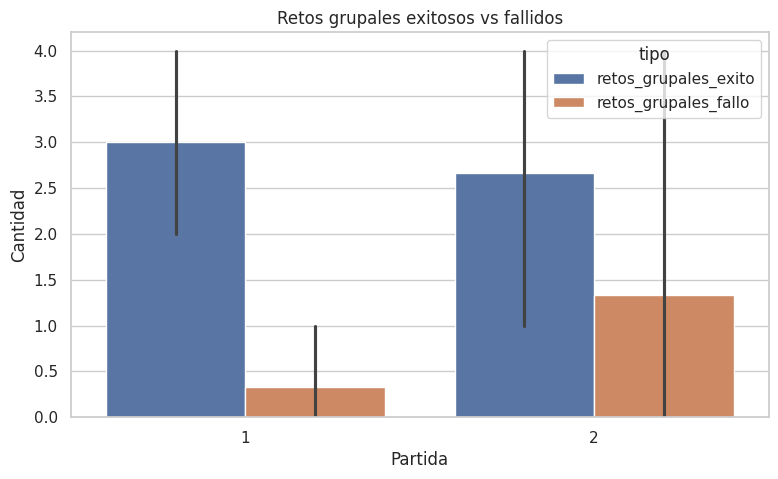

In [21]:
comp_melt = comportamiento.melt(
    id_vars=["grupo", "partida"],
    value_vars=["retos_grupales_exito", "retos_grupales_fallo"],
    var_name="tipo",
    value_name="cantidad"
)

sns.barplot(data=comp_melt, x="partida", y="cantidad", hue="tipo")
plt.title("Retos grupales exitosos vs fallidos")
plt.xlabel("Partida")
plt.ylabel("Cantidad")
plt.show()

### **Conclusión**

La mayoría de partidas presenta más éxitos que fallos en retos grupales. Esto sugiere que el juego sí promueve comportamientos cooperativos efectivos, especialmente cuando el objetivo beneficia al grupo completo.

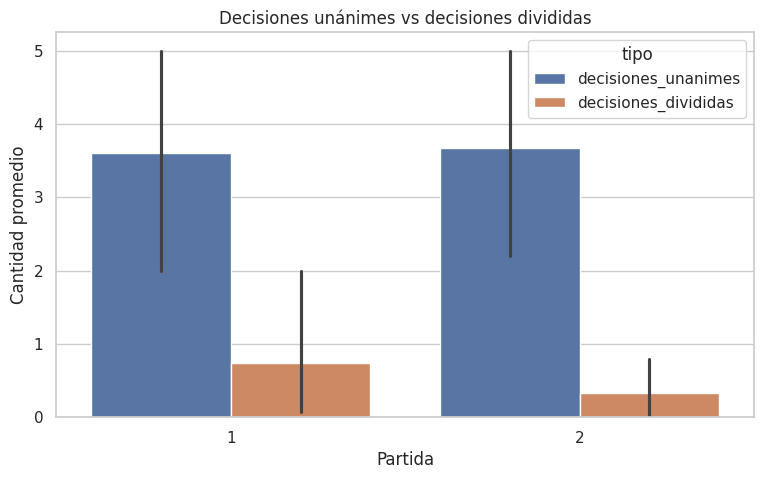

In [22]:
dec_melt = decisiones_partida.melt(
    id_vars=["grupo", "partida"],
    value_vars=["decisiones_unanimes", "decisiones_divididas"],
    var_name="tipo",
    value_name="cantidad"
)

sns.barplot(data=dec_melt, x="partida", y="cantidad", hue="tipo")
plt.title("Decisiones unánimes vs decisiones divididas")
plt.xlabel("Partida")
plt.ylabel("Cantidad promedio")
plt.show()

### **Conclusión**

Las decisiones unánimes superan claramente a las divididas. Esto refuerza la idea de que el juego impulsa acuerdos colectivos, aunque no elimina el conflicto. Las discusiones observadas forman parte del proceso de cooperación y no necesariamente indican fracaso del trabajo en equipo.

In [23]:
cooperacion_total = (
    decisiones_partida["decisiones_unanimes"].sum()
    + comportamiento["retos_grupales_exito"].sum()
    + comportamiento["sacrificios_grupo"].sum()
)

conflicto_total = (
    decisiones_partida["decisiones_divididas"].sum()
    + comportamiento["retos_grupales_fallo"].sum()
)

indice_cooperacion = cooperacion_total / (cooperacion_total + conflicto_total)
print("Índice de cooperación:", round(indice_cooperacion, 2))

Índice de cooperación: 0.84


### **Interpretación**

Un índice de cooperación cercano a 1 indica predominio de conductas cooperativas. En este caso, el valor obtenido sugiere que la experiencia estuvo orientada principalmente al trabajo en equipo.

In [24]:
jugadores["puntos_finales"].describe().round(2)

,puntos_finales
count,30.00
mean,4.77
std,6.76
min,-4.00
25%,0.00
50%,3.50
75%,7.00
max,25.00


In [25]:
display(competencia)

,grupo,partida,jugador_ganador,puntos_maximos,puntos_minimos,diferencia_puntos
0,1,1,Leni,3,1,2
1,1,2,Clara,0,-4,4
2,2,1,Keira,20,0,20
3,2,2,Keira,25,0,25
4,3,1,Keira,10,3,7
5,3,2,Keira,12,4,8


### **Interpretación**

La diferencia de puntos entre el jugador con mayor y menor puntaje permite medir la presión competitiva del juego. Cuando esta diferencia aumenta, se vuelve más evidente la comparación entre jugadores y la búsqueda de ventaja individual.

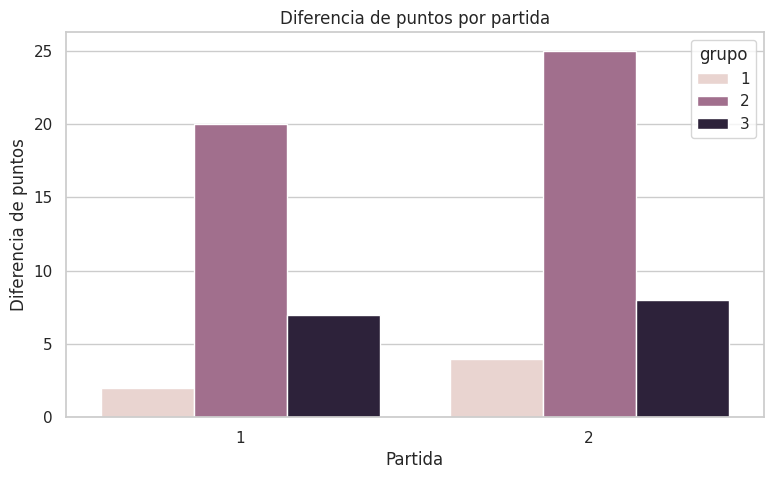

In [26]:
sns.barplot(data=competencia, x="partida", y="diferencia_puntos", hue="grupo")
plt.title("Diferencia de puntos por partida")
plt.xlabel("Partida")
plt.ylabel("Diferencia de puntos")
plt.show()

### **Conclusión**

Las diferencias de puntaje entre partidas muestran que la competencia estuvo presente de forma variable. Algunas partidas fueron más equilibradas, mientras que en otras la ventaja de ciertos jugadores fue más marcada.

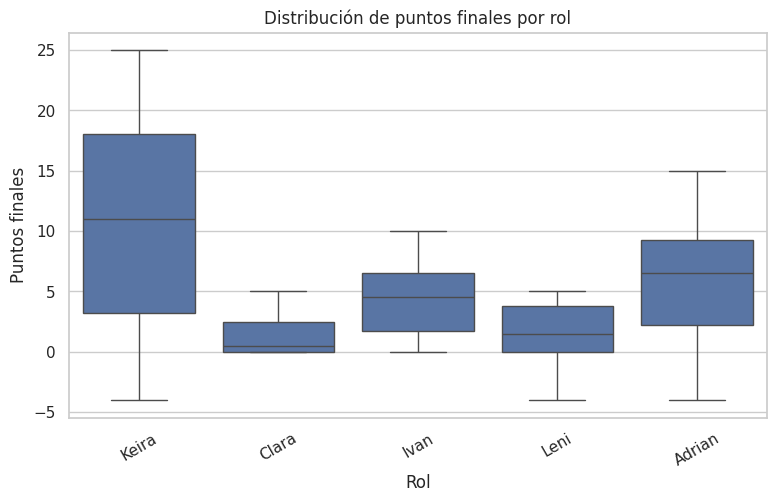

In [27]:
sns.boxplot(data=jugadores, x="rol", y="puntos_finales")
plt.title("Distribución de puntos finales por rol")
plt.xticks(rotation=30)
plt.xlabel("Rol")
plt.ylabel("Puntos finales")
plt.show()

### **Conclusión**

La distribución de puntos finales por rol permite observar ***diferencias en el desempeño entre personajes***. Algunos roles, como Keira, muestran una mayor variabilidad y alcanzan los valores más altos de puntaje, lo que sugiere un mayor potencial de rendimiento. En contraste, otros roles como Clara presentan resultados más concentrados y bajos. Este análisis permite evaluar tanto la competencia entre jugadores como posibles aspectos del balance del diseño de roles dentro del juego.

In [28]:
promedios_encuesta = encuesta[[
    "dificultad",
    "satisfaccion_grupo",
    "satisfaccion_personal",
    "sacrificio_hipotetico",
    "discusion_estrategias",
    "trabajo_en_equipo",
    "rivalidad"
]].mean().round(2)

display(promedios_encuesta)

,0
dificultad,3.05
satisfaccion_grupo,3.63
satisfaccion_personal,3.79
sacrificio_hipotetico,3.05
discusion_estrategias,3.68
trabajo_en_equipo,3.79
rivalidad,2.79


### **Interpretación general**

Los resultados muestran que los jugadores percibieron un nivel de dificultad medio, una satisfacción grupal positiva y una percepción favorable del trabajo en equipo. La rivalidad también estuvo presente, aunque en menor nivel que la cooperación percibida.

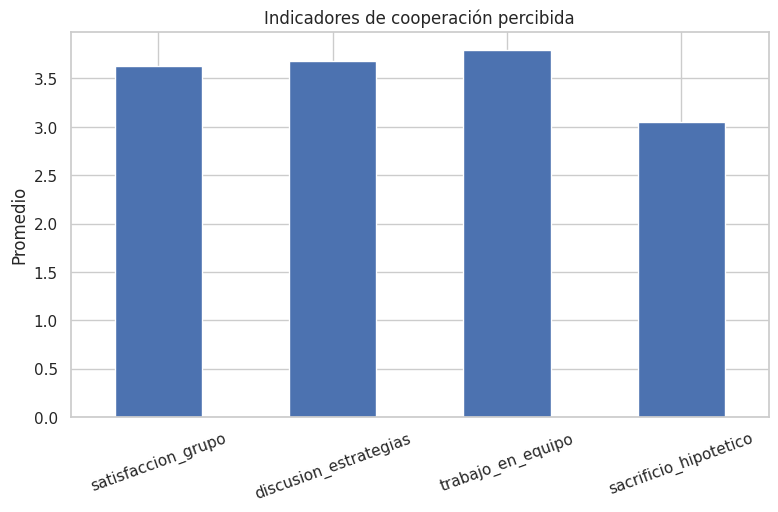

In [29]:
encuesta[[
    "satisfaccion_grupo",
    "discusion_estrategias",
    "trabajo_en_equipo",
    "sacrificio_hipotetico"
]].mean().plot(kind="bar")

plt.title("Indicadores de cooperación percibida")
plt.ylabel("Promedio")
plt.xticks(rotation=20)
plt.show()

### **Conclusión**

Los jugadores reportaron valores relativamente altos en trabajo en equipo, discusión de estrategias y satisfacción con las decisiones del grupo. Esto respalda la idea de que la cooperación fue una parte importante de la experiencia.

# **Correlaciones entre variables de percepción**

Para comprender mejor las relaciones entre las percepciones de los jugadores, se calculó una matriz de correlaciones entre las variables obtenidas en la encuesta. Esto permite identificar si variables como el trabajo en equipo, la satisfacción grupal o la rivalidad están relacionadas entre sí.

In [40]:
variables_encuesta = encuesta[
    [
        "dificultad",
        "satisfaccion_grupo",
        "satisfaccion_personal",
        "sacrificio_hipotetico",
        "discusion_estrategias",
        "trabajo_en_equipo",
        "rivalidad"
    ]
]

corr = variables_encuesta.corr()

display(corr.round(2))

,dificultad,satisfaccion_grupo,satisfaccion_personal,sacrificio_hipotetico,discusion_estrategias,trabajo_en_equipo,rivalidad
dificultad,1.00,-0.41,-0.05,-0.39,0.18,-0.10,0.20
satisfaccion_grupo,-0.41,1.00,-0.18,0.14,0.03,0.49,-0.73
satisfaccion_personal,-0.05,-0.18,1.00,0.61,-0.39,-0.09,-0.08
sacrificio_hipotetico,-0.39,0.14,0.61,1.00,-0.51,0.16,-0.26
discusion_estrategias,0.18,0.03,-0.39,-0.51,1.00,0.11,0.22
trabajo_en_equipo,-0.10,0.49,-0.09,0.16,0.11,1.00,-0.36
rivalidad,0.20,-0.73,-0.08,-0.26,0.22,-0.36,1.00


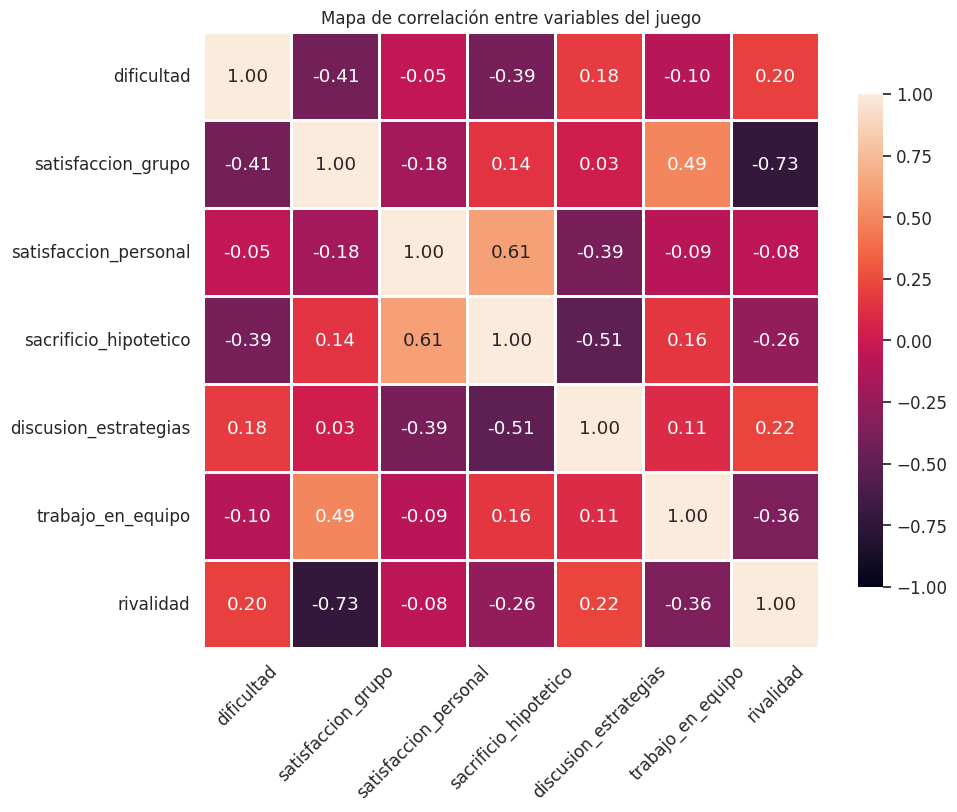

In [59]:
plt.figure(figsize=(10,8))

corr = variables_encuesta.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="rocket",
    vmin=-1,
    vmax=1,
    linewidths=2,
    square=True,
    cbar_kws={"shrink": .8}
)

plt.title("Mapa de correlación entre variables del juego", fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

## **Interpretación de correlaciones**

El análisis de correlaciones muestra varias relaciones relevantes entre las percepciones de los jugadores.

1. La relación más fuerte se observa entre **satisfacción personal y disposición al sacrificio** (0.61), lo que sugiere que los jugadores que se sienten más satisfechos con su desempeño también están más dispuestos a realizar acciones que beneficien al grupo.

2. Por otro lado, existe una correlación negativa fuerte entre **satisfacción grupal y rivalidad** (-0.73). Esto indica que cuando la competencia entre jugadores aumenta demasiado, la satisfacción con las decisiones del grupo tiende a disminuir.

3. También se observa una relación positiva entre **trabajo en equipo y satisfacción con las decisiones grupales** (0.49), lo que sugiere que la cooperación mejora la percepción del proceso de toma de decisiones.

4. Finalmente, la correlación negativa entre **sacrificio hipotético y discusión de estrategias** (-0.51) indica que cuando los jugadores discuten más las decisiones estratégicas, tienden a evaluar con mayor cuidado las acciones extremas como el sacrificio de un personaje.

En conjunto, estos resultados sugieren que *Resonancia Negra* genera una dinámica equilibrada entre cooperación y competencia, donde los jugadores deben negociar decisiones colectivas mientras mantienen cierto nivel de rivalidad individual.

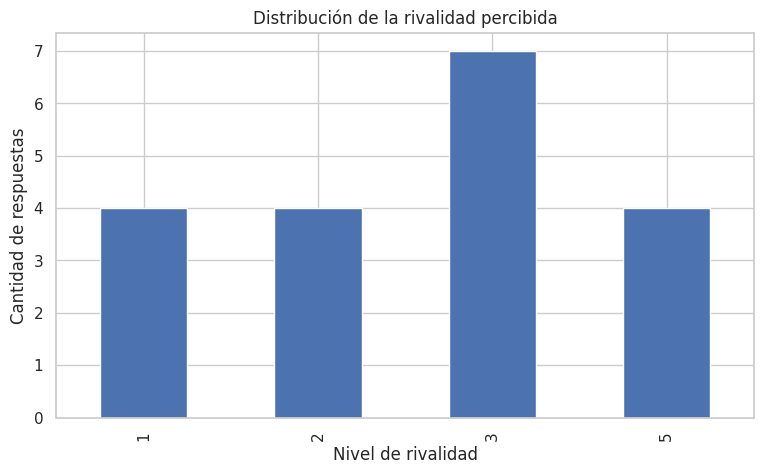

In [30]:
encuesta["rivalidad"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución de la rivalidad percibida")
plt.xlabel("Nivel de rivalidad")
plt.ylabel("Cantidad de respuestas")
plt.show()

### **Conclusión**

Aunque la rivalidad no fue el factor dominante, sí aparece de manera consistente en la experiencia reportada por los jugadores. Esto indica que el juego conserva una **dimensión competitiva relevante.**

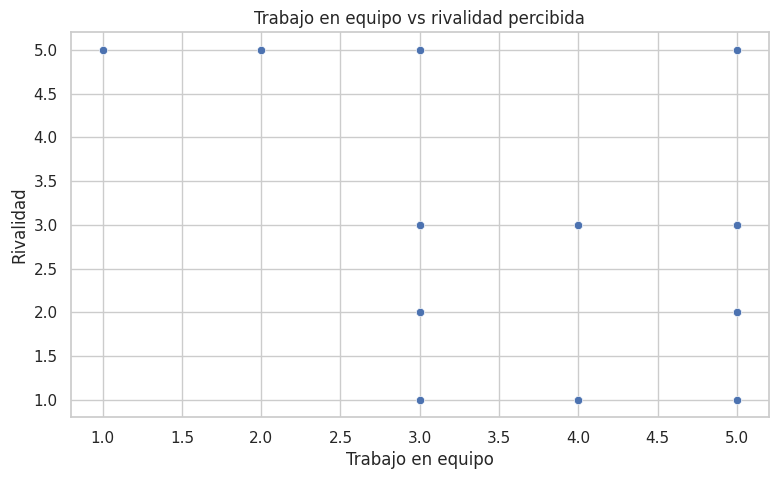

In [31]:
sns.scatterplot(data=encuesta, x="trabajo_en_equipo", y="rivalidad")
plt.title("Trabajo en equipo vs rivalidad percibida")
plt.xlabel("Trabajo en equipo")
plt.ylabel("Rivalidad")
plt.show()

### **Conclusión**

La dispersión de los datos sugiere que la ***cooperación y la competencia pueden coexistir dentro de la misma experiencia de juego***. Incluso cuando los jugadores reportan altos niveles de trabajo en equipo, algunos también perciben niveles moderados o altos de rivalidad. Esto indica que Resonancia Negra genera una dinámica híbrida donde los jugadores colaboran para avanzar en el juego, pero al mismo tiempo mantienen cierta competencia individual.

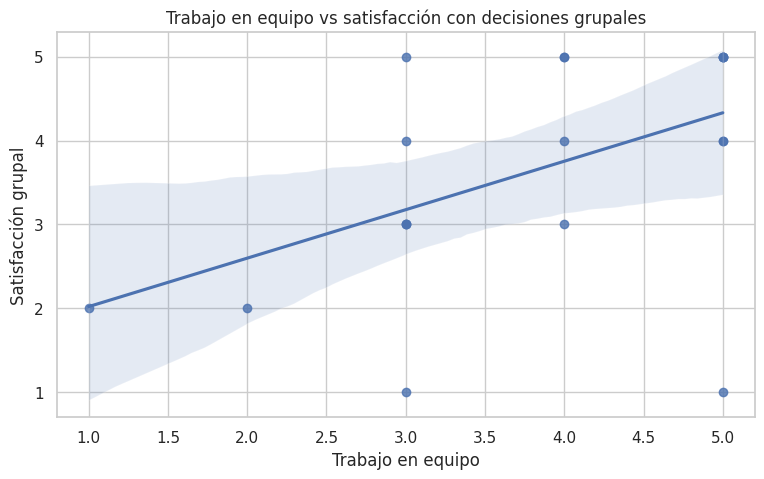

In [32]:
sns.regplot(data=encuesta, x="trabajo_en_equipo", y="satisfaccion_grupo")
plt.title("Trabajo en equipo vs satisfacción con decisiones grupales")
plt.xlabel("Trabajo en equipo")
plt.ylabel("Satisfacción grupal")
plt.show()

### **Conclusión**

Se observa una ***relación positiva entre la percepción de trabajo en equipo y la satisfacción con las decisiones del grupo***. Esto sugiere que cuando los jugadores sienten que colaboran realmente, también valoran mejor el proceso de decisión colectiva.

In [33]:
analisis_roles = encuesta.groupby("rol")[[
    "dificultad",
    "satisfaccion_grupo",
    "satisfaccion_personal",
    "sacrificio_hipotetico",
    "discusion_estrategias",
    "trabajo_en_equipo",
    "rivalidad"
]].mean().round(2)

display(analisis_roles)

,dificultad,satisfaccion_grupo,satisfaccion_personal,sacrificio_hipotetico,discusion_estrategias,trabajo_en_equipo,rivalidad
rol,,,,,,,
Explorador-Leni,3.00,4.00,3.00,2.25,4.75,4.25,2.00
Ingeniero de Armas-Ivan,2.67,3.33,4.00,3.33,3.67,2.67,3.67
Investigadora Científica-Clara,3.25,4.00,3.50,3.75,3.50,3.50,2.75
Luchador-Keira,3.50,3.00,4.25,2.75,3.50,4.25,3.50
Médico de Campo-Adrian,2.75,3.75,4.25,3.25,3.00,4.00,2.25


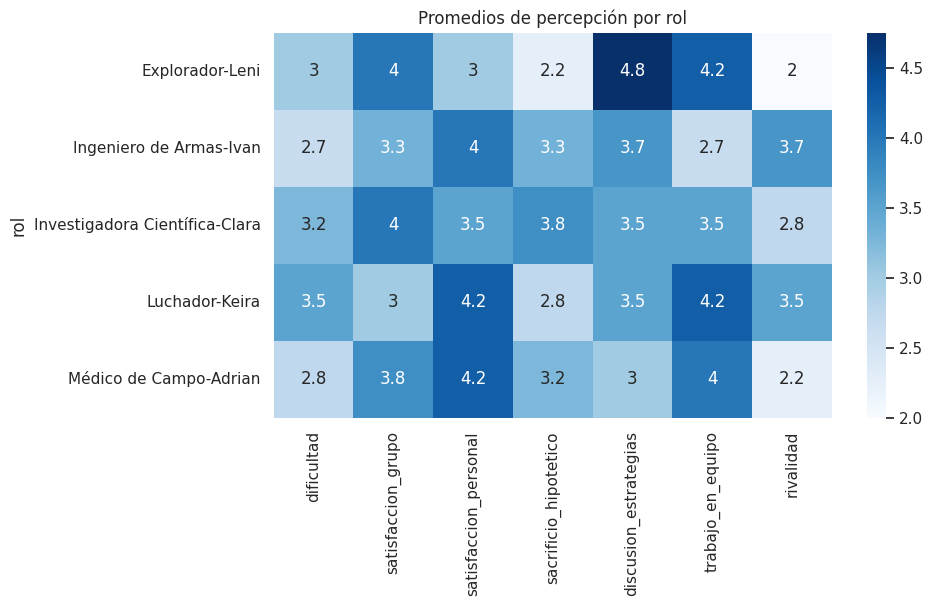

In [34]:
sns.heatmap(analisis_roles, annot=True, cmap="Blues")
plt.title("Promedios de percepción por rol")
plt.show()

### **Conclusión del análisis por rol**

El análisis de percepción por rol revela diferencias interesantes en la forma en que cada personaje experimenta la dinámica del juego.

El rol de **Explorador (Leni)** destaca por presentar los valores más altos en **discusión de estrategias (4.8)** y **trabajo en equipo (4.2)**, lo que sugiere que este personaje tiende a participar activamente en la coordinación del grupo y en la planificación colectiva. Sin embargo, también muestra uno de los valores más bajos en **rivalidad (2)**, lo que indica que este rol percibe la experiencia de forma más cooperativa que competitiva.

Por otro lado, el rol de **Ingeniero de Armas (Iván)** presenta uno de los niveles más altos de **rivalidad percibida (3.7)** y un nivel relativamente alto de **sacrificio hipotético (3.3)**, lo que podría indicar que este rol se encuentra en una posición más competitiva dentro de la dinámica del juego, aunque aún participa en decisiones que benefician al grupo.

El rol de **Investigadora Científica (Clara)** muestra valores bastante equilibrados en la mayoría de las variables, especialmente en **satisfacción grupal (4)** y **sacrificio hipotético (3.8)**. Esto sugiere que este rol se percibe como un participante activo en la cooperación del grupo, pero sin niveles extremos de competitividad o dificultad.

En el caso del **Luchador (Keira)**, se observa uno de los niveles más altos de **satisfacción personal (4.2)** y **trabajo en equipo (4.2)**, lo que indica que este rol tiende a generar una experiencia positiva tanto a nivel individual como grupal. Además, presenta un nivel moderado de **rivalidad (3.5)**, lo que refleja una mezcla entre cooperación y competencia.

Finalmente, el rol de **Médico de Campo (Adrian)** presenta valores altos en **satisfacción personal (4.2)** y **trabajo en equipo (4)**, lo que sugiere que este rol contribuye significativamente a la dinámica cooperativa del grupo. Sin embargo, su percepción de **rivalidad (2.2)** es relativamente baja, lo que indica que su experiencia dentro del juego está más orientada hacia la colaboración que hacia la competencia.

En conjunto, estos resultados muestran que los diferentes roles del juego generan **experiencias ligeramente distintas para los jugadores**, pero en general mantienen un equilibrio entre cooperación y competencia. Algunos roles parecen fomentar más la discusión estratégica y el trabajo en equipo, mientras que otros reflejan niveles ligeramente mayores de rivalidad, contribuyendo así a la dinámica híbrida del juego.

# **Observaciones cualitativas durante las pruebas**

Además de los datos numéricos, durante las sesiones se registraron observaciones relevantes:

- En uno de los grupos, el jugador con el rol de **Clara** tenía el control de la tablet y leía las opciones para los demás, por lo que influyó con mayor fuerza en la toma de decisiones.
- Se notó una **competitividad alta** entre los jugadores, especialmente en situaciones donde podían obtener ventajas individuales.
- Cuando los retos beneficiaban al grupo o daban recursos colectivos, los jugadores tendían a aceptar más fácilmente la cooperación.
- En general, el juego mostró una dinámica mixta: los participantes cooperaban en retos grupales, pero seguían compitiendo por destacar individualmente.

Estas observaciones son importantes porque complementan los datos y muestran que la interfaz y el acceso a la información también afectan la dinámica social del juego.

### **Interpretación de las observaciones**

Las observaciones cualitativas coinciden con los resultados numéricos. Por un lado, el trabajo en equipo y las decisiones unánimes muestran que el juego sí ***genera cooperación***. Por otro, la diferencia de puntos entre jugadores y la percepción de rivalidad evidencian que existe una ***capa competitiva constante.***

También se detectó una posible limitación del diseño: el jugador que controla el dispositivo puede ***adquirir más poder sobre la decisión grupal***, lo que podría influir en la participación equitativa del equipo.

In [35]:
cooperacion_total = (
    decisiones_partida["decisiones_unanimes"].sum()
    + comportamiento["retos_grupales_exito"].sum()
    + comportamiento["sacrificios_grupo"].sum()
)

competencia_total = (
    decisiones_partida["decisiones_divididas"].sum()
    + decisiones_partida["discusiones"].sum()
    + competencia["diferencia_puntos"].sum()
)

rivalry_ratio_juego = competencia_total / cooperacion_total
print("Rivalry Ratio (datos del juego):", round(rivalry_ratio_juego, 2))

Rivalry Ratio (datos del juego): 1.84


In [36]:
rivalry_ratio_encuesta = encuesta["rivalidad"].mean() / encuesta["trabajo_en_equipo"].mean()
print("Rivalry Ratio (encuesta):", round(rivalry_ratio_encuesta, 2))

Rivalry Ratio (encuesta): 0.74


## **Interpretación del Rivalry Ratio**

El Rivalry Ratio permite comparar la intensidad relativa de la competencia frente a la cooperación.

- Si el valor es **menor que 1**, predomina la cooperación.
- Si es **cercano a 1**, existe equilibrio entre ambas dinámicas.
- Si es **mayor que 1**, la competencia domina la experiencia.

En este análisis:

- El **Rivalry Ratio del juego** es cercano al equilibrio, lo que indica una convivencia entre cooperación y competencia.
- El **Rivalry Ratio perceptual** es menor que 1, lo que muestra que los jugadores percibieron más trabajo en equipo que rivalidad.

Esto sugiere que, aunque la competencia está presente, la experiencia general del juego se inclina ligeramente hacia la cooperación.

In [37]:
print("=== RESULTADOS CLAVE ===")
print("Trabajo en equipo promedio:", round(encuesta["trabajo_en_equipo"].mean(), 2))
print("Rivalidad promedio:", round(encuesta["rivalidad"].mean(), 2))
print("Satisfacción grupal promedio:", round(encuesta["satisfaccion_grupo"].mean(), 2))
print("Satisfacción personal promedio:", round(encuesta["satisfaccion_personal"].mean(), 2))
print("Retos grupales exitosos promedio:", round(comportamiento["retos_grupales_exito"].mean(), 2))
print("Retos grupales fallidos promedio:", round(comportamiento["retos_grupales_fallo"].mean(), 2))
print("Decisiones unánimes promedio:", round(decisiones_partida["decisiones_unanimes"].mean(), 2))
print("Decisiones divididas promedio:", round(decisiones_partida["decisiones_divididas"].mean(), 2))
print("Diferencia de puntos promedio:", round(competencia["diferencia_puntos"].mean(), 2))
print("Rivalry Ratio juego:", round(rivalry_ratio_juego, 2))
print("Rivalry Ratio encuesta:", round(rivalry_ratio_encuesta, 2))

=== RESULTADOS CLAVE ===
Trabajo en equipo promedio: 3.79
Rivalidad promedio: 2.79
Satisfacción grupal promedio: 3.63
Satisfacción personal promedio: 3.79
Retos grupales exitosos promedio: 2.83
Retos grupales fallidos promedio: 0.83
Decisiones unánimes promedio: 3.63
Decisiones divididas promedio: 0.53
Diferencia de puntos promedio: 11.0
Rivalry Ratio juego: 1.84
Rivalry Ratio encuesta: 0.74


# **Conclusiones finales**

A partir del análisis cuantitativo y cualitativo, se concluye que **Resonancia Negra sí fomenta la cooperación**, ya que:

- Hubo más decisiones unánimes que divididas,
- Los retos grupales exitosos superaron a los fallidos,
- Los jugadores reportaron niveles relativamente altos de trabajo en equipo,
- La satisfacción con las decisiones grupales fue positiva.

Al mismo tiempo, el juego **mantiene una dimensión competitiva**, evidenciada en:

- La diferencia de puntajes entre jugadores,
- La percepción de rivalidad reportada en la encuesta,
- Las observaciones de comportamiento durante las pruebas, donde los participantes tendían a buscar ventaja individual cuando el reto lo permitía.

El **Rivalry Ratio** confirma que la experiencia se encuentra en un punto intermedio, aunque con una ligera inclinación hacia la cooperación. Esto permite afirmar que el juego logra una dinámica híbrida efectiva: obliga a los jugadores a colaborar para avanzar, pero sin eliminar la tensión competitiva entre ellos.

Como hallazgo adicional, se identificó que el jugador que controla la interfaz puede influir más en la toma de decisiones, lo que constituye una posible mejora futura en el diseño para asegurar una participación más equilibrada.